In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI

/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI


In [4]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [7]:
tbl_all = Table.read_table('/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI/BHuynh_Personal_Informatics.csv')
tbl_all.labels

('WeekID',
 'day ID',
 'DayOfWeek',
 'date',
 'Time Exercising (Min) ',
 'Time Studying (Min)',
 'Emotion (0 = low, 1 = med, 2 = high)',
 'Time Reading (Min) ',
 'Sleep (Over 8 hours = 1, Under 8 hours = 0) ',
 'Number of Diary Entries ')

## **Personal Informatics Correlations:**
## 1. Time spent exercising and emotional status

In [37]:
tbl_1 = tbl_all.select('Time Exercising (Min) ', 'Emotion (0 = low, 1 = med, 2 = high)')
tbl_1

Time Exercising (Min),"Emotion (0 = low, 1 = med, 2 = high)"
32,0
82,1
24,1
115,2
0,0
0,2
21,1
53,2
46,1
112,0


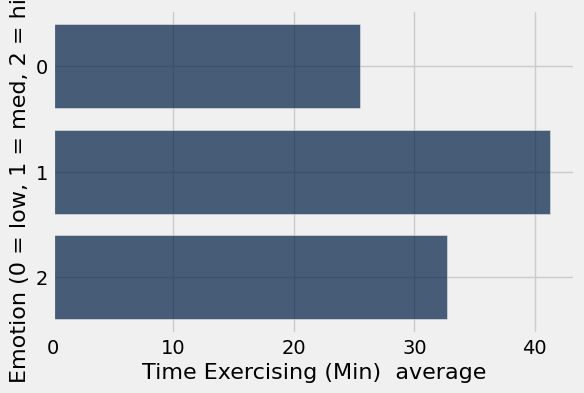

In [49]:
tbl_1.group('Emotion (0 = low, 1 = med, 2 = high)', np.average).barh('Emotion (0 = low, 1 = med, 2 = high)')

In [50]:
means_table = tbl_1.group('Emotion (0 = low, 1 = med, 2 = high)', np.average)
means_table

"Emotion (0 = low, 1 = med, 2 = high)",Time Exercising (Min) average
0,25.5
1,41.25
2,32.7


In [51]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

15.75

In [42]:
#function to calcuate difference of means
def difference_of_means(table, var1, var2):
    """
    table: name of table,
    var1: column label of numerical variable,
    var2: column label of group-label variable, a discrete variable
    Returns: Difference of means of the two groups"""
    #table with the two relevant columns
    reduced = table.select(var1, var2)
    # table containing group means
    means_table = reduced.group(var2, np.average)
    # array of group means
    means = means_table.column(1)
    return means.item(1) - means.item(0)

In [43]:
difference_of_means(tbl_1, 'Time Exercising (Min) ', 'Emotion (0 = low, 1 = med, 2 = high)')

15.75

In [33]:
#step 2: run simulation
#2a function to run one iteration of simulation
def one_simulated_difference(table, var1, var2):
    """
    table: name of table
    var1: column label of numerical variable,
    var2: column label of group-label variable, a discrete avariable
    Returns: Difference of means of the two groups after shuffling labels"""
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled Label', shuffled_labels)
    return difference_of_means(shuffled_table, var1, 'Shuffled Label')

In [44]:
one_simulated_difference(tbl_1, 'Time Exercising (Min) ', 'Emotion (0 = low, 1 = med, 2 = high)')

10.708333333333336

In [45]:
#2b: function to run multiple iterations of simulation
differences = make_array()
for i in np.arange(100):
    new_difference = one_simulated_difference(tbl_1, 'Time Exercising (Min) ', 'Emotion (0 = low, 1 = med, 2 = high)') # update
    differences = np.append(differences, new_difference)
differences

array([ -5.625     , -12.375     ,   5.5       , -10.33333333,
        -2.33333333,  11.54166667,  -4.79166667,   7.91666667,
        12.54166667, -25.20833333,  16.875     , -27.5       ,
        20.54166667, -26.        ,   6.        , -11.16666667,
        27.75      ,  -8.125     ,   0.66666667, -14.79166667,
        18.625     ,  -3.91666667,   2.66666667, -14.        ,
         1.25      ,  -6.66666667, -19.375     ,   6.        ,
        20.33333333,   6.91666667,   4.83333333,  16.95833333,
       -11.75      ,   8.875     ,   3.95833333,  10.79166667,
       -27.08333333,  -3.875     , -10.91666667,   7.29166667,
        -2.95833333,   6.95833333, -38.125     , -17.33333333,
         6.66666667,   5.625     , -13.91666667, -16.58333333,
         6.66666667,  -1.625     ,  21.125     ,  -1.95833333,
         8.45833333,  13.58333333,   4.04166667,  -1.29166667,
        16.79166667,  11.91666667,  27.54166667,  10.83333333,
        -0.5       ,  -4.58333333,   5.33333333,   6.08

Observed Difference: 15.75
p-value= 0.84


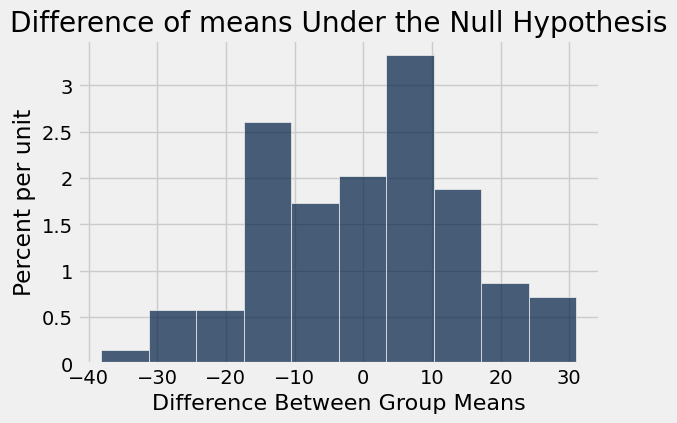

In [46]:
# step 3: visualize and interprete results
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
print('p-value=',np.mean(differences<observed_difference))
plots.title('Difference of means Under the Null Hypothesis');

## 2. Time spent studying and time spent exercising

In [53]:
tbl_2 = tbl_all.select('Time Exercising (Min) ', 'Time Studying (Min)')
tbl_2

Time Exercising (Min),Time Studying (Min)
32,150
82,90
24,30
115,30
0,0
0,0
21,90
53,200
46,30
112,45


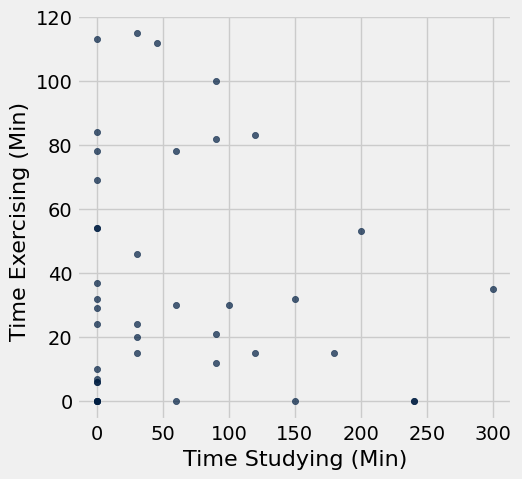

In [67]:
tbl_2.scatter('Time Studying (Min)','Time Exercising (Min) ')

In [68]:
#step1: determine test statistics
correlation_matrix = np.corrcoef(tbl_2.column('Time Studying (Min)'),tbl_2.column('Time Exercising (Min) '))
correlation_coefficient = correlation_matrix[0, 1]
correlation_coefficient

-0.094600116073735238

In [69]:
def get_cor(table, var1, var2):
    """
    table: name of table,
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    return: correlation coefficient as a numeric value"""
    correlation_matrix = np.corrcoef(table.column(var1),table.column(var2))
    my_result = correlation_matrix[0, 1]
    return my_result

In [70]:
observed_correlation = get_cor(tbl_2,'Time Studying (Min)', 'Time Exercising (Min) ')
observed_correlation

-0.094600116073735238

In [71]:
#step 2: run simulation
#2a function to run one iteration of simulation
def one_simulated_cor(table, var1, var2):
    """
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    Returns: correlation between two variables after shuffling"""
    shuffled_var2 = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled var2', shuffled_var2)
    return get_cor(shuffled_table, var1, 'Shuffled var2')

In [72]:
#test the function above
one_simulated_cor(tbl_2,'Time Studying (Min)', 'Time Exercising (Min) ') # update

0.10376916882125628

In [73]:
#2b: function to run multiple iterations of simulation
cor_list = make_array()
for i in np.arange(100):
    new_cor = one_simulated_cor(tbl_2,'Time Studying (Min)', 'Time Exercising (Min) ') # update
    cor_list= np.append(cor_list, new_cor)
cor_list

array([-0.1546023 , -0.05261583, -0.10580742,  0.05945721,  0.17161646,
       -0.09606569, -0.12132523,  0.07665611, -0.03494277, -0.22124265,
       -0.13029107,  0.07622506,  0.30149188,  0.30149188, -0.0437362 ,
       -0.02101985,  0.27670649,  0.21566979,  0.09226013,  0.05307767,
       -0.09641053,  0.14247747,  0.10911419, -0.1262392 , -0.21119919,
        0.03294763, -0.1047729 ,  0.15721939, -0.14024833,  0.05600881,
        0.12256296, -0.26874438, -0.02847702, -0.02502862,  0.11182981,
       -0.16524924,  0.20929025,  0.00932608,  0.2268771 ,  0.06471602,
       -0.13554988, -0.12490294,  0.12027839, -0.02959775, -0.0978761 ,
        0.20881609, -0.07201309,  0.04626708,  0.04066342, -0.02408031,
       -0.25016612, -0.11149728,  0.1486846 , -0.03214095, -0.07481491,
        0.1676508 ,  0.03493046,  0.22049755,  0.08070799, -0.09050514,
        0.24222248,  0.04092206,  0.09514817,  0.01712809, -0.11666988,
        0.08325118, -0.20132814,  0.07083694, -0.14020522,  0.11

Observed correlation: -0.0946001160737
p-value= 0.7


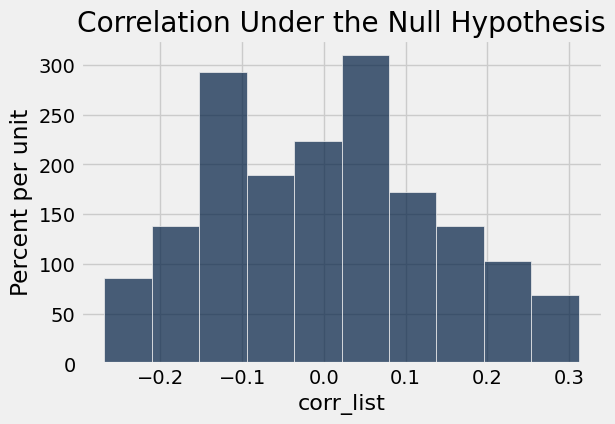

In [74]:
# step 3: visualize and interprete results
Table().with_column('corr_list', cor_list).hist()
print('Observed correlation:',observed_correlation)
print('p-value=',np.mean(cor_list>observed_correlation)) # update: change the sign < or > to according to your problem
plots.title('Correlation Under the Null Hypothesis');